# Customer Pareto and lifetime value

Where should account attention concentrate? Three questions:

1. What share of customers generates 80% of profit?
2. Who are the top 20 by lifetime profit, and what do they have in common?
3. Do the three segments differ on margin and order value?

The customer rollup comes from the CTE written in Phase 4, loaded straight out of
`sql/03_advanced_queries.sql` rather than reimplemented here, so the notebook and the SQL
report cannot drift apart.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import plotting as viz
from src.utils import load_analysis_frame

viz.apply_style()
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

from src.run_sql_report import parse_queries, run_query
from src.utils import SQL_DIR, connect, load_analysis_frame

queries = {q.name: q for q in parse_queries((SQL_DIR / "03_advanced_queries.sql").read_text(encoding="utf-8"))}
con = connect(read_only=True)

lifetime = run_query(con, queries["customer_lifetime_value"])
pareto = run_query(con, queries["customer_profit_pareto"])
print(f"{len(lifetime):,} customers")
lifetime.head(3)

793 customers


,customer_id,customer_name,segment,orders,order_lines,lifetime_sales,lifetime_profit,margin_pct,avg_order_value,first_order,last_order,days_active
0,TC-20980,Tamara Chand,Corporate,5,12,19052.22,8981.32,47.14,3810.44,2017-11-07,2019-11-26,749
1,RB-19360,Raymond Buch,Consumer,6,18,15117.34,6976.10,46.15,2519.56,2019-04-01,2020-09-25,543
2,SC-20095,Sanjit Chand,Consumer,9,22,14142.33,5757.41,40.71,1571.37,2017-02-12,2020-01-15,1067


## The Pareto curve

Customers sorted by lifetime profit, most profitable first, with profit accumulated down the
list.

findfont: Failed to find font weight semibold, now using 700.


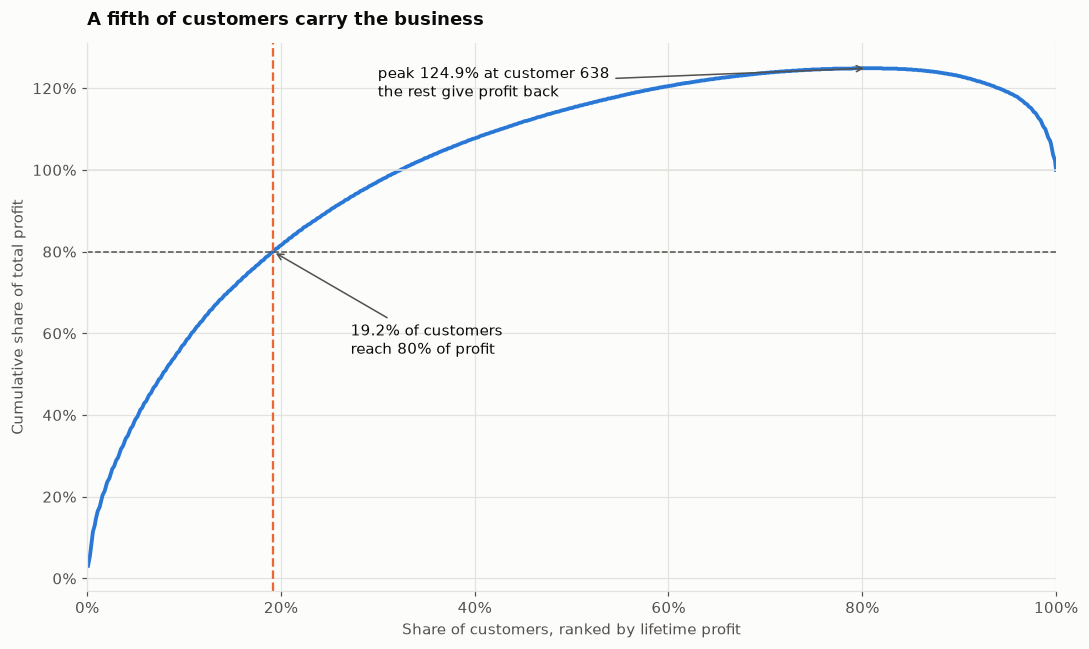

,top_pct_of_customers,pct_of_profit
0,5,39.0
1,10,57.3
2,20,81.4
3,30,97.1
4,50,115.1


In [2]:
total_profit = lifetime["lifetime_profit"].sum()
peak_row = pareto.loc[pareto["cumulative_profit"].idxmax()]

# The classic reading: how few customers does it take to reach 80% of net profit?
reach_80 = pareto[pareto["pct_of_total_profit"] >= 80].iloc[0]

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(pareto["pct_of_customers"], pareto["pct_of_total_profit"],
        color=viz.CATEGORICAL[0], linewidth=2.5, label="cumulative profit")
ax.axhline(80, color=viz.INK_MUTED, linewidth=1, linestyle="--")
ax.axhline(100, color=viz.GRID, linewidth=1)
ax.axvline(reach_80["pct_of_customers"], color=viz.CATEGORICAL[1], linewidth=1.5,
           linestyle="--")

ax.annotate(
    f"{reach_80['pct_of_customers']:.1f}% of customers\nreach 80% of profit",
    xy=(reach_80["pct_of_customers"], 80), xytext=(reach_80["pct_of_customers"] + 8, 55),
    fontsize=10, color=viz.INK,
    arrowprops=dict(arrowstyle="->", color=viz.INK_MUTED, linewidth=1),
)
ax.annotate(
    f"peak {peak_row['pct_of_total_profit']:.1f}% at customer "
    f"{int(peak_row['profit_rank']):,}\nthe rest give profit back",
    xy=(peak_row["pct_of_customers"], peak_row["pct_of_total_profit"]),
    xytext=(30, 118), fontsize=10, color=viz.INK,
    arrowprops=dict(arrowstyle="->", color=viz.INK_MUTED, linewidth=1),
)

ax.set_xlabel("Share of customers, ranked by lifetime profit")
ax.set_ylabel("Cumulative share of total profit")
ax.set_title("A fifth of customers carry the business")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_xlim(0, 100)

fig.tight_layout()
viz.save_figure(fig, "customer_profit_pareto")
plt.show()

milestones = pd.DataFrame([
    {"top_pct_of_customers": p,
     "pct_of_profit": pareto[pareto["pct_of_customers"] <= p]["pct_of_total_profit"].max()}
    for p in (5, 10, 20, 30, 50)
])
milestones.round(1)

**19.2% of customers generate 80% of profit.** That is about as close to a textbook 80/20 as
real data gets.

The curve does something a Pareto chart usually does not: it climbs past 100%, peaking at
**124.9% at the 638th customer**, then falls back to 100%. That overshoot is not an error. It
means the profitable customers generate roughly a quarter more profit than the business
actually keeps, and the remaining 155 customers hand a quarter of it back.

Quoting "the top 20% generate 80% of profit" is true but understates the concentration. The
sharper statement is that **the top fifth generate four fifths of profit while the bottom
fifth destroy a quarter of it**.

## The customers who cost money

In [3]:
losers = run_query(con, queries["loss_making_customers"])
overall_discount = con.execute("SELECT avg(discount) FROM fact_sales").fetchone()[0]

print(f"{len(losers)} of {len(lifetime)} customers ({100 * len(losers) / len(lifetime):.1f}%) "
      f"lose money overall")
print(f"combined losses: ${abs(losers['lifetime_profit'].sum()):,.2f}")
print(f"their average discount: {losers['avg_discount'].mean():.1%} "
      f"against {overall_discount:.1%} overall")

losers.head(10).round(2)

155 of 793 customers (19.5%) lose money overall
combined losses: $71,224.49
their average discount: 23.8% against 15.6% overall


,customer_id,customer_name,segment,orders,lifetime_sales,lifetime_profit,avg_discount
0,CS-12505,Cindy Stewart,Consumer,6,5690.06,-6626.39,0.20
1,GT-14635,Grant Thornton,Corporate,3,9351.21,-4108.66,0.25
2,LF-17185,Luke Foster,Consumer,7,3930.51,-3583.98,0.32
3,SR-20425,Sharelle Roach,Home Office,5,3233.48,-3333.91,0.37
4,HG-14965,Henry Goldwyn,Corporate,12,3247.64,-2797.96,0.17
5,NC-18415,Nathan Cano,Consumer,6,2218.99,-2204.81,0.26
6,SB-20290,Sean Braxton,Corporate,7,8057.89,-2082.75,0.24
7,SM-20320,Sean Miller,Home Office,5,25043.05,-1980.74,0.25
8,CP-12340,Christine Phan,Corporate,8,5888.28,-1850.30,0.21
9,NF-18385,Natalie Fritzler,Consumer,7,8322.83,-1695.97,0.25


155 customers, 19.5% of the book, lose **$71,224** between them.

Their average discount is **23.8% against 15.6% for everyone else**. That lands them on the
wrong side of the 20% cliff found in the discount analysis, which is the same finding arriving
from a completely different direction. The customer problem and the pricing problem are the
same problem.

## The top 20 by lifetime profit

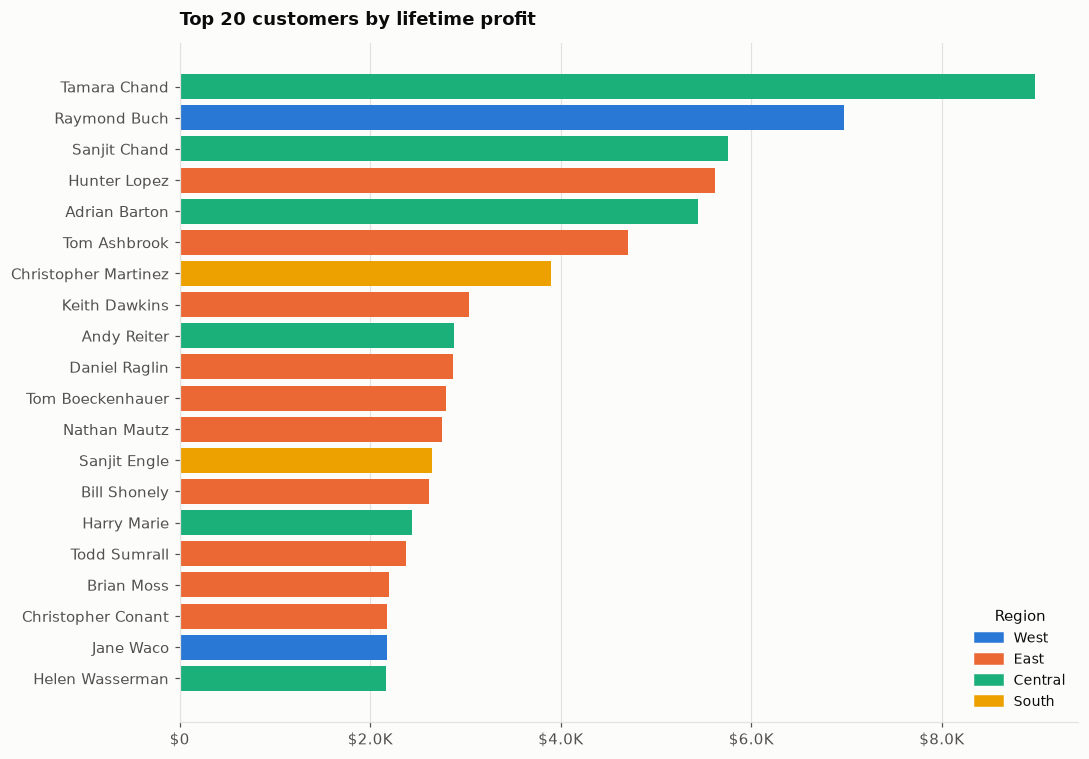

segment mix of the top 20:
segment
Consumer       9
Corporate      8
Home Office    3

region mix of the top 20:
region
East       10
Central     6
West        2
South       2

top 20 contribute $74,518.76, 26.0% of total profit, from 2.5% of customers


In [4]:
# A customer can order into more than one region, so attribute them to where they spend most.
frame = load_analysis_frame()
dominant_region = (
    frame.groupby(["customer_id", "region"])["sales"].sum()
    .reset_index()
    .sort_values("sales", ascending=False)
    .drop_duplicates("customer_id")
    .set_index("customer_id")["region"]
)

top20 = lifetime.head(20).copy()
top20["region"] = top20["customer_id"].map(dominant_region)

fig, ax = plt.subplots(figsize=(10, 7))
order = top20.sort_values("lifetime_profit")
ax.barh(order["customer_name"], order["lifetime_profit"],
        color=[viz.REGION_COLORS[r] for r in order["region"]])
ax.set_title("Top 20 customers by lifetime profit")
ax.xaxis.set_major_formatter(plt.FuncFormatter(viz.currency))

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in viz.REGION_COLORS.values()]
ax.legend(handles, viz.REGION_COLORS.keys(), loc="lower right", fontsize=9, title="Region")
ax.grid(axis="y", visible=False)

fig.tight_layout()
viz.save_figure(fig, "top_20_customers")
plt.show()

print("segment mix of the top 20:")
print(top20["segment"].value_counts().to_string())
print("\nregion mix of the top 20:")
print(top20["region"].value_counts().to_string())
print(f"\ntop 20 contribute ${top20['lifetime_profit'].sum():,.2f}, "
      f"{100 * top20['lifetime_profit'].sum() / total_profit:.1f}% of total profit, "
      f"from {len(top20) / len(lifetime):.1%} of customers")

**The top 20 customers, 2.5% of the book, deliver 26.0% of all profit.**

The segment mix is the interesting part for account planning: 9 Consumer, 8 Corporate, 3 Home
Office. Corporate is over-represented, holding 40% of the top 20 while making up only 29.8% of
customers (236 of 793). Consumer is under-represented on the same basis, 45% of the list
against 51.6% of customers. The best accounts skew Corporate even though the segment averages
say the three are alike.

These are the accounts where a service failure or a defection is expensive, and they are few
enough that named ownership is realistic.

## Segment comparison

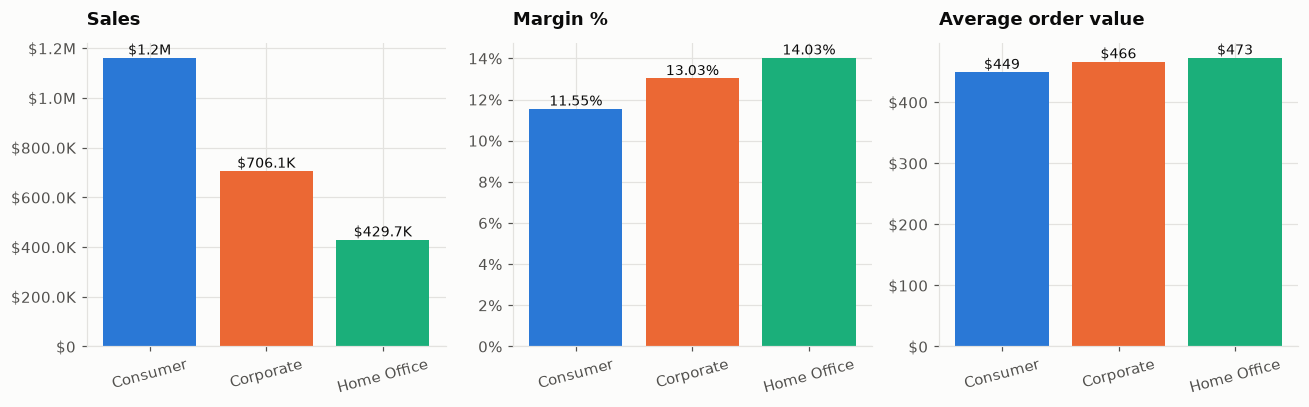

,segment,customers,orders,sales,profit,margin_pct,avg_order_value,avg_discount
0,Consumer,409,2586,1161401.34,134119.21,11.55,449.11,0.16
1,Corporate,236,1514,706146.37,91979.13,13.03,466.41,0.16
2,Home Office,148,909,429653.15,60298.68,14.03,472.67,0.15


In [5]:
segments = run_query(con, {q.name: q for q in parse_queries(
    (SQL_DIR / "02_fundamental_queries.sql").read_text(encoding="utf-8")
)}["sales_profit_margin_by_segment"])

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))

for ax, col, title, fmt in [
    (axes[0], "sales", "Sales", viz.currency),
    (axes[1], "margin_pct", "Margin %", lambda v, _: f"{v:.0f}%"),
    (axes[2], "avg_order_value", "Average order value", viz.currency),
]:
    ax.bar(segments["segment"], segments[col],
           color=[viz.SEGMENT_COLORS[s] for s in segments["segment"]])
    ax.set_title(title)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(fmt))
    ax.tick_params(axis="x", rotation=15)
    for x, v in enumerate(segments[col]):
        label = f"{v:,.2f}%" if col == "margin_pct" else viz.currency(v)
        ax.annotate(label, (x, v), ha="center", va="bottom", fontsize=9, color=viz.INK)

fig.tight_layout()
viz.save_figure(fig, "segment_comparison")
plt.show()

segments.round(2)

The segments are more alike than different. **Home Office carries the best margin at 14.03%,
Consumer the worst at 11.55%**, a spread of under 2.5 points, and average order value sits
between $449 and $473 for all three.

That is a useful negative result. Segment is not where the profit problem lives, so segmenting
the discount policy by customer type would be solving the wrong variable. The problem is
product-level pricing, and it shows up in every segment at roughly the same rate: the share of
loss-making lines runs 17.5% to 19.3% across the three.

## Conclusion

**Concentrate attention on the top fifth and cap the discounts reaching the bottom fifth.**

- 19.2% of customers generate 80% of profit; the top 20 alone generate 26.0%.
- 155 customers lose $71,224 between them, at an average discount of 23.8%.
- Segment explains almost nothing. Margin varies by under 2.5 points across the three.

The loss-making customers are not a different kind of customer. They are ordinary customers
being sold to past the discount ceiling identified in the previous notebook.